In [94]:
import scipy as sp
#from scipy.misc import derivative
from scipy.special import jv, hankel2, hankel1, yv, jvp, yvp, factorial
import numpy as np
import matplotlib.pyplot as plt
from numpy import sqrt, linspace, zeros, ones, pi, exp, conj, argmin, unravel_index, log, einsum, tan, log10, acosh, cosh, sinh, tanh, acos, cos, sin
import torch
import warnings
warnings.filterwarnings("ignore")
from utils import h_z_cpa, h_z_cpa_numerator, e_z_cpa, e_z_cpa_numerator, hl2_prime, hl1_prime, hbar, c, alpha, graphene_conductivity
tau = 6.4*1e-13 # scattering time in seconds

### The approximations here are taken from (or derived using Equations 8.452 and 8.453 of "Table of Integrals, Series, and Products, Seventh Edition I.S. Gradshteyn and I.M. Ryzhik"

In [95]:
def j_nu_approximation(x, m):
    alpha = acosh(m/x)
    beta = acos(m/x)
    approx_array_x_lt_m = exp(m*tanh(alpha)-m*alpha)/sqrt(2*pi*m*tanh(alpha))
    approx_array_x_gt_m = sqrt(2/(m*pi*tan(beta)))*cos(m*tan(beta)-m*beta-pi/4)
    approx_array = np.where(x<m, approx_array_x_lt_m, approx_array_x_gt_m)
    return approx_array


def y_nu_approximation(x, m):
    alpha = acosh(m/x)
    beta = acos(m/x)
    approx_array_x_lt_m = -2*exp(-m*tanh(alpha)+m*alpha)/sqrt(2*pi*m*tanh(alpha))
    approx_array_x_gt_m = sqrt(2/(m*pi*tan(beta)))*sin(m*tan(beta)-m*beta-pi/4)
    approx_array = np.where(x<m, approx_array_x_lt_m, approx_array_x_gt_m)
    return approx_array

In [96]:
def j_nu_prime_approximation(x, m):
    nu_approx = j_nu_approximation(x, m)
    nu_minus_one_approx = j_nu_approximation(x, m-1)
    return nu_minus_one_approx - (m/x)*nu_approx


def y_nu_prime_approximation(x, m):
    nu_approx = y_nu_approximation(x, m)
    nu_minus_one_approx = y_nu_approximation(x, m-1)
    return nu_minus_one_approx - (m/x)*nu_approx

In [97]:
def j_nu_prime_approximation_closed_form(x, m):
    alpha = acosh(m/x)
    beta = acos(m/x)
    approx_array_x_lt_m = exp(m*tanh(alpha)-m*alpha)/sqrt(2*pi*m*tanh(alpha))*sinh(alpha)
    approx_array_x_gt_m = -sqrt(2/(m*pi*tan(beta)))*sin(m*tan(beta)-m*beta-pi/4)*sin(beta)
    approx_array = np.where(x<m, approx_array_x_lt_m, approx_array_x_gt_m)
    return approx_array

def y_nu_prime_approximation_closed_form(x, m):
    alpha = acosh(m/x)
    beta = acos(m/x)
    approx_array_x_lt_m = 2*exp(-m*tanh(alpha)+m*alpha)/sqrt(2*pi*m*tanh(alpha))*sinh(alpha)
    approx_array_x_gt_m = sqrt(2/(m*pi*tan(beta)))*cos(m*tan(beta)-m*beta-pi/4)*sin(beta)
    approx_array = np.where(x<m, approx_array_x_lt_m, approx_array_x_gt_m)
    return approx_array

In [98]:
m = 190
M = 1000
x = linspace(150, 300, M)

In [99]:
jv_exact = jv(m, x)
jv_approx = j_nu_approximation(x, m)

yv_exact = yv(m, x)
yv_approx = y_nu_approximation(x, m)

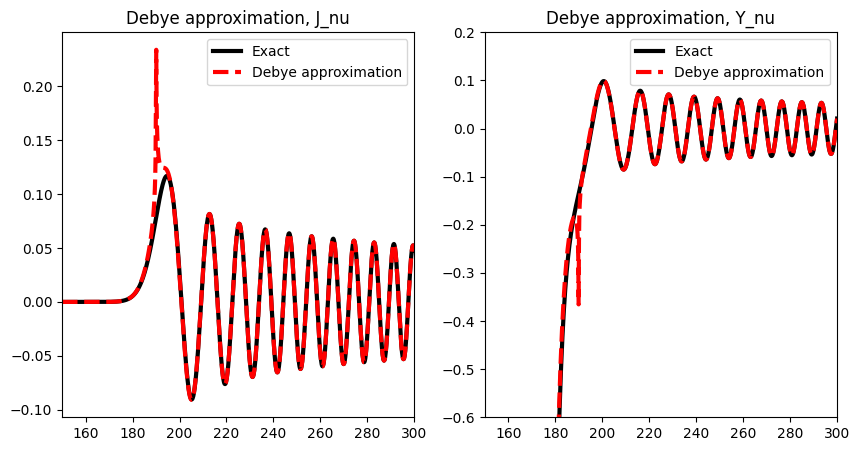

In [100]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))
ax1.plot(x, jv_exact, color="black", linewidth=3, label="Exact")
ax1.plot(x, jv_approx, color="red", linestyle="dashed", linewidth=3, label="Debye approximation")
ax1.set_xlim(x.min(), x.max());

ax2.plot(x, yv_exact, color="black", linewidth=3, label="Exact")
ax2.plot(x, yv_approx, color="red", linestyle="dashed", linewidth=3, label="Debye approximation")
ax2.set_xlim(x.min(), x.max());
ax2.set_ylim(-0.6, 0.2);

ax1.legend()
ax2.legend()
ax1.set_title("Debye approximation, J_nu")
ax2.set_title("Debye approximation, Y_nu");

### Now we do approximations for the derivatives

In [101]:
M = 1000
x = linspace(150, 300, M)

#jv_prime_exact = jvp(m, x, 1)
#jv_prime_approx = j_nu_prime_approximation(x, m)

jv_prime_exact = jvp(m, x, 1)
jv_prime_approx = j_nu_prime_approximation_closed_form(x, m)

#yv_prime_exact = yvp(m, x, 1)
#yv_prime_approx = y_nu_prime_approximation(x, m)

yv_prime_exact = yvp(m, x, 1)
yv_prime_approx = y_nu_prime_approximation_closed_form(x, m)

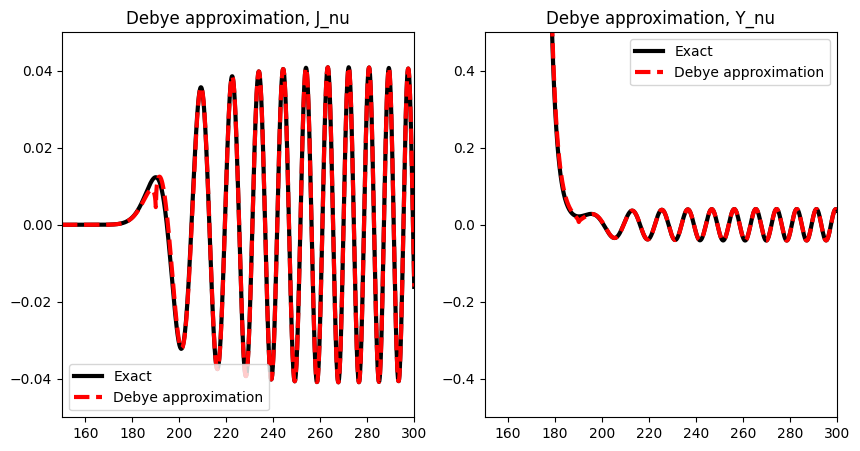

In [102]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))
ax1.plot(x, jv_prime_exact, color="black", linewidth=3, label="Exact")
ax1.plot(x, jv_prime_approx, color="red", linestyle="dashed", linewidth=3, label="Debye approximation")
ax1.set_xlim(x.min(), x.max());
ax1.set_ylim(-0.05, 0.05)

ax2.plot(x, yv_prime_exact, color="black", linewidth=3, label="Exact")
ax2.plot(x, yv_prime_approx, color="red", linestyle="dashed", linewidth=3, label="Debye approximation")
ax2.set_xlim(x.min(), x.max());
ax2.set_ylim(-0.5, 0.5);

ax1.legend()
ax2.legend()
ax1.set_title("Debye approximation, J_nu")
ax2.set_title("Debye approximation, Y_nu");